# Import libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Import and load data

In [51]:
df= pd.read_csv("Mall_Customers.csv")
df.head(20)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# Understanding the data

In [10]:
df.info()
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data cleaning

In [15]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

# EDA

In [26]:
df.groupby('Gender')['Spending Score (1-100)'].sum()

Gender
Female    5771
Male      4269
Name: Spending Score (1-100), dtype: int64

In [88]:
df.groupby('Gender')["Annual Income (k$)"].mean()

Gender
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64

In [27]:
df.groupby('Gender')['Spending Score (1-100)'].mean()

Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64

In [28]:
df.groupby('Gender')['Spending Score (1-100)'].max()

Gender
Female    99
Male      97
Name: Spending Score (1-100), dtype: int64

In [29]:
df.groupby('Gender')['Spending Score (1-100)'].min()

Gender
Female    5
Male      1
Name: Spending Score (1-100), dtype: int64

In [32]:
df.groupby('Gender')['Spending Score (1-100)'].median()

Gender
Female    50.0
Male      50.0
Name: Spending Score (1-100), dtype: float64

In [99]:
df['age groups']=pd.cut(df['Age'],
bins=[1,25,30,45,55,60,100],
labels=['18-25','26-30','31-45','46-55','56-60','61+'])


In [94]:
df.groupby('age groups')['Spending Score (1-100)'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_19000\506791945.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age groups')['Spending Score (1-100)'].mean()


age groups
18-25    54.947368
26-30    70.666667
31-45    52.569444
46-55    36.702703
56-60    30.166667
61+      44.176471
Name: Spending Score (1-100), dtype: float64

In [54]:
df.groupby("Annual Income (k$)")["Spending Score (1-100)"].mean()

Annual Income (k$)
15     60.0
16     41.5
17     58.0
18     50.0
19     47.0
       ... 
103    48.5
113    49.5
120    47.5
126    51.0
137    50.5
Name: Spending Score (1-100), Length: 64, dtype: float64

In [100]:
df['age groups'].value_counts()

age groups
31-45    72
18-25    38
46-55    37
26-30    24
61+      17
56-60    12
Name: count, dtype: int64

In [104]:
df['Spender Type'] = pd.cut(df["Spending Score (1-100)"],
                           bins=[0, 40, 70, 100],
                           labels=['Low', 'Medium', 'High'])

df['Spender Type'].value_counts()

Spender Type
Medium    83
Low       63
High      54
Name: count, dtype: int64

Text(0.5, 1.0, 'Annual score vs Spending score')

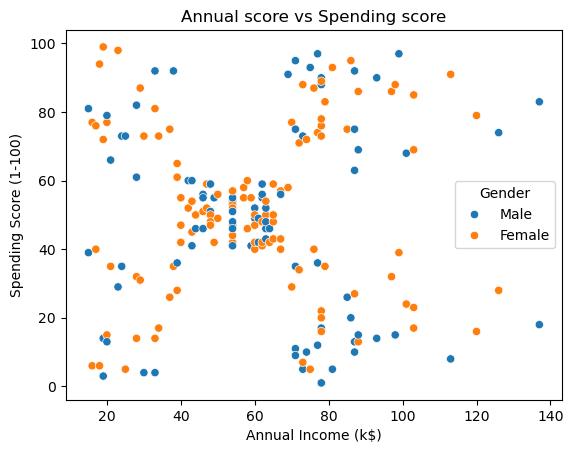

In [74]:
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)",data=df,hue="Gender")
plt.title('Annual score vs Spending score')


# visualization

<Axes: xlabel='Spender Type', ylabel='count'>

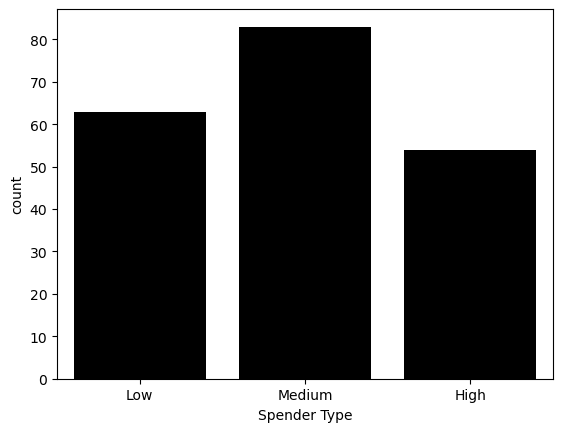

In [110]:
sns.countplot(x='Spender Type', data=df,color='black')

<Axes: xlabel='Gender', ylabel='count'>

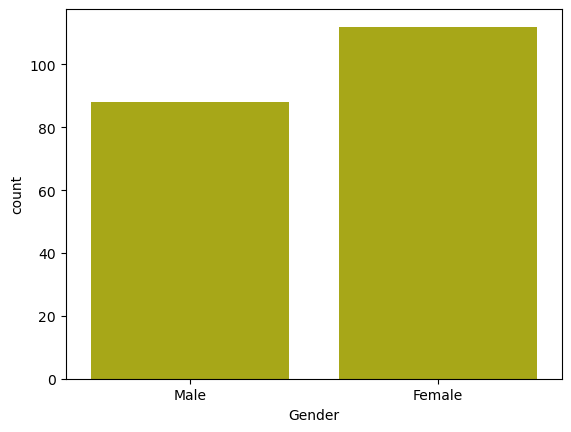

In [79]:
sns.countplot(x='Gender',data=df,color='y')

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

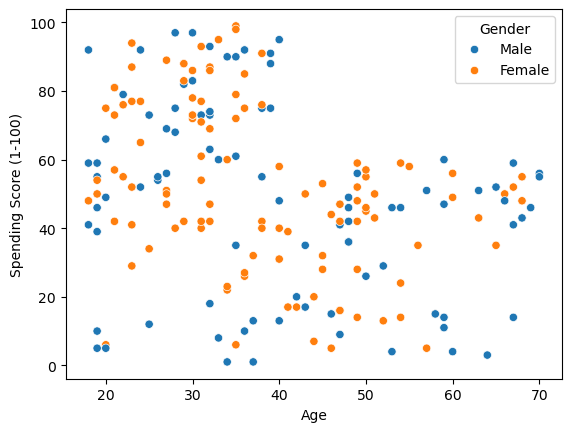

In [86]:
sns.scatterplot(x="Age", y="Spending Score (1-100)",data=df,hue="Gender")

## INSIGHTS:
Males are having more annual income than females but still females are spending more on average than males.   
Males are having more annual income than females,so thee is a chance to improve their buying interest.  
since female customers are more than males, therefore, females are high spenders.  
High income does not guarantee high spending.  
Young customers (26-30) are high spenders. So, they are an important  group for sales. 
There are clear customer segments(Medium spender are more).  
